# 04 — Unsupervised clustering

Fits KMeans / Gaussian-mixture clustering on **train** embeddings only (no labels used), then checks how well the resulting clusters agree with the true tissue class on held-out data — via `src/analysis/clustering.py`.

This asks a different question than the linear probe in `docs/RESULTS.md`: not "is this representation linearly separable given labels", but "do objects group into natural clusters that line up with tissue classes, with no supervision at all". A CLI version of the same pipeline is available as `python -m src.run_clustering` for scripted use.

Uses the same `REPRESENTATIONS` / synthetic-fallback pattern as `03_latent_space_analysis.ipynb`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parents[0]))

from src.analysis.clustering import (
    ClusteringConfig,
    evaluate_clustering,
    fit_clustering_model,
    predict_clusters,
)
from src.analysis.embedding_projection import (
    compute_2d_projection,
    plot_projection,
)

## Load representations

Unlike notebook 03 (which only needs a single, already-split embeddings file), clustering needs **train** and **test** embeddings separately, so the model is fit without ever seeing test-set features (same discipline as `src/analysis/linear_probe.py`).

In [2]:
REPRESENTATIONS = {
    "rgb_vae": (
        "./outputs/runs/20260716_181630_crc_pilot_vae_beta_1/evaluation/train/embeddings.csv",
        "./outputs/runs/20260716_181630_crc_pilot_vae_beta_1/evaluation/test/embeddings.csv",
        "latent_",
    ),
    "grayscale_vae": (
        "./outputs/runs/20260717_000412_crc_pilot_grayscale_vae_beta_1/evaluation/train/embeddings.csv",
        "./outputs/runs/20260717_000412_crc_pilot_grayscale_vae_beta_1/evaluation/test/embeddings.csv",
        "latent_",
    ),
    # "rgb_hsv_color_baseline": (
    #     "../outputs/color_features/train_features.csv",
    #     "../outputs/color_features/test_features.csv",
    #     "color_",
    # ),
}

available_representations = {}

for label, (train_path, test_path, feature_prefix) in REPRESENTATIONS.items():
    if Path(train_path).exists() and Path(test_path).exists():
        available_representations[label] = (
            pd.read_csv(train_path),
            pd.read_csv(test_path),
            feature_prefix,
        )

print(f"Found {len(available_representations)} real representation(s).")

Found 2 real representation(s).


In [3]:
if not available_representations:
    print(
        "No real embeddings found — using the synthetic "
        "dataset with the classical color-feature extractor "
        "as a stand-in representation."
    )

    from src.analysis.color_features import extract_color_feature_frame
    from src.datasets.split import assign_patient_splits
    from src.datasets.synthetic import generate_synthetic_histology_dataset

    synthetic_metadata = generate_synthetic_histology_dataset(
        output_dir="../data/raw/synthetic_patches",
        metadata_path="../data/metadata/synthetic_metadata.csv",
        num_patients=15,
        slides_per_patient=1,
        patches_per_slide=10,
        image_size=64,
        seed=2,
    )
    synthetic_metadata = assign_patient_splits(
        metadata=synthetic_metadata,
        train_fraction=0.6,
        validation_fraction=0.2,
        test_fraction=0.2,
        seed=2,
        stratify_column=None,
    )

    color_frame = extract_color_feature_frame(synthetic_metadata)

    available_representations = {
        "synthetic_color_features": (
            color_frame[color_frame["split"] == "train"],
            color_frame[color_frame["split"] == "test"],
            "color_",
        ),
    }

## Fit clustering (train-only) and evaluate (test-only)

`class_column` is `class_code` for the real CRC data (9 tissue classes) and falls back to `label` for the synthetic dataset, which has no class codes.

In [4]:
NUMBER_OF_CLUSTERS = 9  # 9 tissue classes in the real CRC pilot

comparison_rows = []
fitted_models = {}

for label, (train_frame, test_frame, feature_prefix) in available_representations.items():
    class_column = (
        "class_code" if "class_code" in test_frame.columns else "label"
    )
    number_of_clusters = min(
        NUMBER_OF_CLUSTERS,
        test_frame[class_column].nunique(),
        len(train_frame) - 1,
    )

    config = ClusteringConfig(
        number_of_clusters=number_of_clusters,
        algorithm="kmeans",
        seed=42,
    )

    fitted_model = fit_clustering_model(train_frame, feature_prefix, config)
    evaluation = evaluate_clustering(fitted_model, test_frame, class_column=class_column)

    fitted_models[label] = (fitted_model, test_frame, class_column)
    comparison_rows.append({"representation": label, **evaluation.summary()})

comparison_table = pd.DataFrame(comparison_rows).sort_values(
    "cluster_purity", ascending=False
)
comparison_table

,representation,number_of_samples,number_of_clusters,cluster_purity,adjusted_rand_index,normalized_mutual_info
0,rgb_vae,1800,9,0.382778,0.196520,0.281076
1,grayscale_vae,1800,9,0.364444,0.168669,0.278053


## Visualize the best representation's clusters vs. true classes

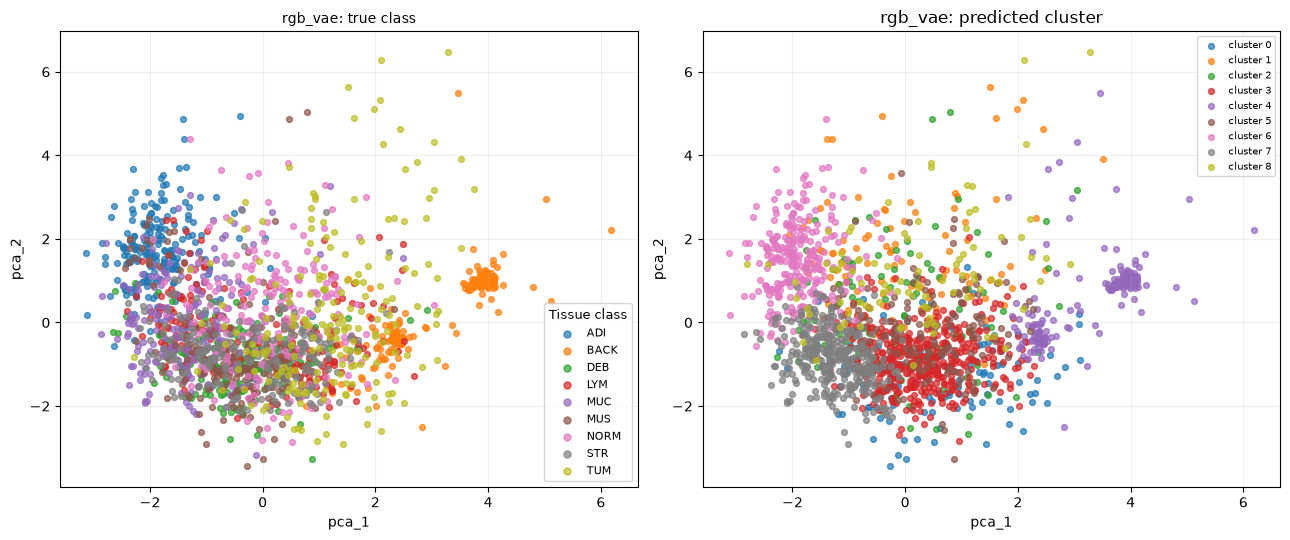

In [5]:
best_label = comparison_table.iloc[0]["representation"]
best_fitted_model, best_test_frame, best_class_column = fitted_models[best_label]

cluster_assignments = predict_clusters(best_fitted_model, best_test_frame)

projection = compute_2d_projection(
    best_test_frame, best_fitted_model.feature_prefix, method="pca"
)

fig, (true_class_ax, cluster_ax) = plt.subplots(1, 2, figsize=(13, 5.5))

plot_projection(projection, ax=true_class_ax, title=f"{best_label}: true class")

for cluster_id in sorted(set(cluster_assignments)):
    mask = cluster_assignments == cluster_id
    cluster_ax.scatter(
        projection.coordinates.loc[mask, "proj_1"],
        projection.coordinates.loc[mask, "proj_2"],
        label=f"cluster {cluster_id}",
        alpha=0.7,
        s=18,
    )
cluster_ax.set_title(f"{best_label}: predicted cluster")
cluster_ax.set_xlabel("pca_1")
cluster_ax.set_ylabel("pca_2")
cluster_ax.legend(fontsize=7)
cluster_ax.grid(alpha=0.2)

plt.tight_layout()

## Notes

- `cluster_purity` rewards many small, pure clusters, while `adjusted_rand_index` and `normalized_mutual_info` are more balanced overall-agreement measures — read all three together, not `cluster_purity` alone.
- Because clustering never sees labels during fitting, a low agreement here does not contradict a high linear-probe score in `docs/RESULTS.md`: linear separability and natural cluster structure are genuinely different properties of a representation.
- For the real CRC data, re-run `python -m src.run_clustering` (see README → "Extended experiments") after `src/evaluate.py` to get a saved, reproducible `metrics.json` instead of only this notebook's in-memory result.